<a href="https://colab.research.google.com/github/DeepthiGovindapuram/PredictiveAnalysis/blob/SAP1/sap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Sample Data:
   GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  Research  \
0        333          119                  3  3.5  4.2  6.39         0   
1        298           94                  2  3.6  1.2  8.27         1   
2        317          103                  3  3.5  2.9  7.80         0   
3        302          115                  3  2.6  2.1  9.47         0   
4        295          107                  1  2.7  2.6  6.36         0   

   Chance of Admit  
0              1.0  
1              1.0  
2              1.0  
3              1.0  
4              1.0  

Model Evaluation:
Mean Squared Error: 0.0
R^2 Score: 1.0

Model Coefficients:
Intercept: 1.0
  GRE Score: 0.0000
  TOEFL Score: 0.0000
  University Rating: 0.0000
  SOP: 0.0000
  LOR: 0.0000
  CGPA: 0.0000
  Research: 0.0000


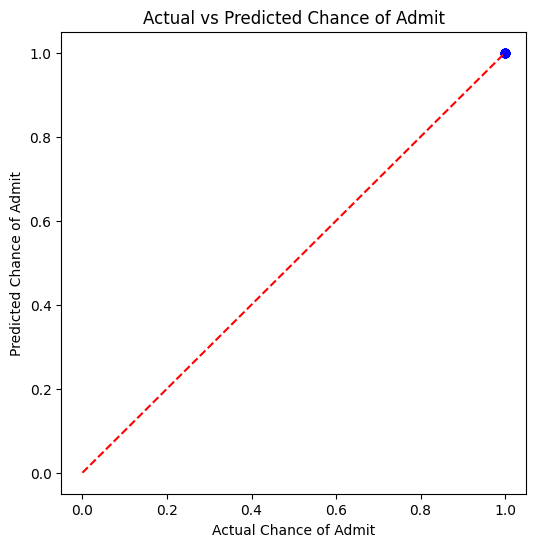

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


data = pd.DataFrame({
    "GRE Score": np.random.randint(290, 340, 100),
    "TOEFL Score": np.random.randint(90, 120, 100),
    "University Rating": np.random.randint(1, 5, 100),
    "SOP": np.round(np.random.uniform(1, 5, 100), 1),
    "LOR": np.round(np.random.uniform(1, 5, 100), 1),
    "CGPA": np.round(np.random.uniform(6.0, 10.0, 100), 2),
    "Research": np.random.randint(0, 2, 100)
})


data["Chance of Admit"] = (
    0.003 * data["GRE Score"]
    + 0.0025 * data["TOEFL Score"]
    + 0.02 * data["University Rating"]
    + 0.03 * data["SOP"]
    + 0.03 * data["LOR"]
    + 0.08 * data["CGPA"]
    + 0.1 * data["Research"]
    + np.random.normal(0, 0.02, 100)
)

data["Chance of Admit"] = data["Chance of Admit"].clip(0, 1)

print("\nSample Data:")
print(data.head())


X = data.drop(columns=["Chance of Admit"])
y = data["Chance of Admit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)



print("\nModel Evaluation:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

print("\nModel Coefficients:")
print("Intercept:", model.intercept_)
for feat, coef in zip(X.columns, model.coef_):
    print(f"  {feat}: {coef:.4f}")

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Actual Chance of Admit')
plt.ylabel('Predicted Chance of Admit')
plt.title('Actual vs Predicted Chance of Admit')
plt.show()
